# Clustering mixed-type tabular data with `forest_clustering`

### An end-to-end tutorial on the UCI **Adult** census dataset

This notebook is a hands-on walkthrough of the `forest_clustering` library applied to the
full **Adult** dataset (48,842 rows, mixed numerical + categorical features). We will:

1. Load and explore the data.
2. Explain and build the **random-partition similarity embedding** the library is based on.
3. Cluster with the library's three paths — **KMeans** (centroid), **Louvain** and **Leiden**
   (graph community detection).
4. Inspect which large-`n` paths avoid a dense `n x n` distance matrix and where that
   claim does and does not apply.
5. **Compare against scikit-learn baselines** (KMeans, Gaussian Mixture, Agglomerative).
6. **Compare the library's own settings** against each other (bins, iterations, clusterer).

> **A note on evaluation.** Adult is a *classification* dataset; its `income` label
> (`<=50K` / `>50K`) is **not** a ground-truth clustering. We use it only as a weak external
> reference (ARI / NMI) -- modest scores are expected because income is one of *many* latent
> structures in the data. We therefore also report **silhouette** (internal cohesion) and
> qualitative cluster profiles. We use one fixed seed for runtime reasons; a real analysis
> should repeat seeds and test partition stability.


## 1. Setup and data loading

The schema is the [UCI Adult / Census Income dataset](https://archive.ics.uci.edu/dataset/2/adult). For a self-contained executable example we read a combined CSV mirror when no local `data/adult-all.csv` is present. Missing values are denoted by `?`; because `skipinitialspace=True` removes the preceding space, `na_values='?'` is the correct parser setting. We then keep missingness as an explicit categorical level.

In [1]:
import time, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)
from scipy.sparse.csgraph import connected_components

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import forest_clustering as fcmod
from forest_clustering import ForestClusterer
print("forest_clustering version:", fcmod.__version__)
RNG = 0

forest_clustering version: 0.9.1


In [2]:
# The Adult dataset. A repository-local cache is used when present.
COLS = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]
local_candidates = [
    PROJECT_ROOT / "data" / "adult-all.csv",
    PROJECT_ROOT / "adult-all.csv",
]
local_path = next((path for path in local_candidates if path.exists()), None)
source = local_path or "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(
    source, header=None, names=COLS, na_values="?", skipinitialspace=True
)

# Clean target to a binary label and drop it from the feature matrix.
df["income"] = df["income"].astype(str).str.contains(">50K").astype(int)
y = df["income"].values
X = df.drop(columns=["income"]).copy()
missing_before_fill = int(X.isna().sum().sum())
for c in X.select_dtypes("object").columns:
    X[c] = X[c].fillna("Missing")
print(f"Data source: {source}")
print(f"Missing categorical values represented explicitly: {missing_before_fill:,}")
print(f"Rows: {len(X):,}   Features: {X.shape[1]}   >50K rate: {y.mean():.3f}")
X.head()

Rows: 48,842   Features: 14   >50K rate: 0.239


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### A quick look at the feature types

In [3]:
dtypes = X.dtypes.apply(
    lambda t: "numerical" if pd.api.types.is_numeric_dtype(t) else "categorical"
)
pd.DataFrame({"dtype": dtypes, "n_unique": X.nunique()})

,dtype,n_unique
age,numerical,74
workclass,categorical,9
fnlwgt,numerical,28523
education,categorical,16
education_num,numerical,16
marital_status,categorical,7
occupation,categorical,15
relationship,categorical,6
race,categorical,5
sex,categorical,2


The data is genuinely **mixed**: continuous columns like `age` and `hours_per_week`
alongside high-cardinality categoricals like `occupation` and `native_country`.
A key convenience of `forest_clustering` is that it consumes this DataFrame **directly** --
it detects column types internally, so no manual scaling or one-hot encoding is required.
The scikit-learn baselines below, by contrast, need explicit preprocessing.

## 2. The random-partition similarity embedding

`forest_clustering` does not cluster the raw features. Instead it builds an **embedding**:

- It runs `L = n_iterations` random partitions. Each iteration picks a random subset of
  features, bins them, and assigns every row a **cell id** -- an integer identifying which
  cell of that random partition the row fell into.
- The embedding is the `(n, L)` matrix of cell ids. Two rows are **similar** if they land in
  the *same cell* across many iterations -- i.e. their **Hamming distance** (fraction of
  differing iterations) is small.

This turns arbitrary mixed-type data into a uniform integer code on which a single, principled
similarity (Hamming) is defined. Crucially, each column behaves like a **locality-sensitive
hash**, which is what lets the library scale later on.

In [4]:
t0 = time.time()
fc = ForestClusterer(n_iterations=200, n_bins=4, n_clusters=2,
                     corr_threshold=None, random_state=RNG)
fc.fit(X)                      # builds the embedding and clusters with default KMeans
E = fc.embedding_
fc_time = time.time() - t0
print(f"Embedding shape: {E.shape}   built+clustered in {fc_time:.1f}s")
print("A few opaque cell-id rows (only equality within a column is meaningful):")
pd.DataFrame(E[:4, :8])

Embedding shape: (48842, 200)   built+clustered in 0.7s
A few cell-id rows (ids are 52-bit hashes; only equality is meaningful):


,0,1,2,3,4,5,6,7
0,4205274760157275,4205274760769281,4205274760784132,4205274816076418,4205274760746277,4205274760746466,4205274817133362,4205274817604421
1,4205274760157275,4205274763221081,4205274760755390,4205274817603586,4205274760746275,4205274760752962,4205274817603716,4205274817603590
2,4205274760157274,4205274818365616,4205274759993522,4205274763184186,4205274760752963,4205274760752903,4205274817133362,4205274817862497
3,4205274760157275,4205274763540622,4205274759993522,4205274763184186,4205274760751300,4205274760752962,4205274763532331,4205274760752902


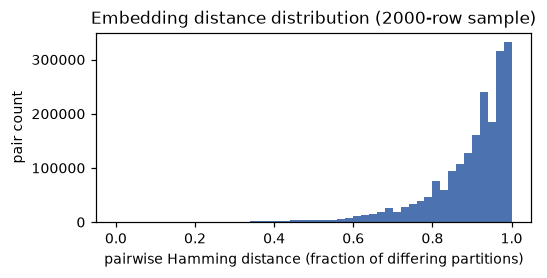

median pairwise distance: 0.925


In [5]:
# How concentrated are the pairwise Hamming distances? (sample for speed)
rng = np.random.default_rng(RNG)
idx = rng.choice(len(E), 2000, replace=False)
Es = E[idx]
H = (Es[:, None, :] != Es[None, :, :]).mean(2)          # fraction of differing iterations
tri = H[np.triu_indices(len(Es), k=1)]
plt.figure(figsize=(5, 2.6))
plt.hist(tri, bins=50, color="#4C72B0")
plt.xlabel("pairwise Hamming distance (fraction of differing partitions)")
plt.ylabel("pair count"); plt.title("Embedding distance distribution (2000-row sample)")
plt.tight_layout(); plt.show()
print(f"median pairwise distance: {np.median(tri):.3f}")

## 3. Clustering with the library

The library exposes three clustering paths, all on top of the same embedding:

| `clusterer` | family | how it scales on large `n` |
|---|---|---|
| an sklearn estimator (default `KMeans`) | centroid | sparse one-hot features; no pairwise matrix |
| `'louvain'` | graph community detection | exact dense path for small `n`, approximate sparse kNN path for large `n` |
| `'leiden'`  | graph community detection | same graph construction, optional `leidenalg` backend |

We already ran default KMeans with `k=2`, matching the number of income classes only for a
controlled weak-reference comparison. The graph methods instead infer a community count.
For the full Adult data we use `k=100` and `resolution=0.05`: a denser neighbourhood graph
and lower resolution than the defaults. These values were chosen exploratorily to reduce
fragmentation; they are not self-tuned and do not guarantee a small number of clusters.
Disconnected graph components cannot be merged by lowering resolution, so we inspect
connectivity before interpreting the communities.

In [6]:
def cluster_profile(labels, name):
    lab = labels[labels >= 0]
    sizes = pd.Series(lab).value_counts()
    return {"method": name,
            "n_clusters": len(np.unique(lab)),
            "median_cluster_size": round(float(sizes.median()), 1),
            "largest_%": round(100 * sizes.max() / len(labels), 1),
            "noise_%": round(100 * (labels < 0).mean(), 1)}

results_lib, timings = {}, {}
results_lib["forest+KMeans"] = fc.labels_
timings["forest+KMeans"] = fc_time

t0 = time.time()
fc_leiden = ForestClusterer(n_iterations=200, n_bins=4,
                            clusterer="leiden:k=100,resolution=0.05",
                            corr_threshold=None, random_state=RNG).fit(X)
timings["forest+Leiden"] = time.time() - t0
results_lib["forest+Leiden"] = fc_leiden.labels_

t0 = time.time()
fc_louvain = ForestClusterer(n_iterations=200, n_bins=4,
                             clusterer="louvain:k=100,resolution=0.05",
                             corr_threshold=None, random_state=RNG).fit(X)
timings["forest+Louvain"] = time.time() - t0
results_lib["forest+Louvain"] = fc_louvain.labels_

display(pd.DataFrame([cluster_profile(v, k) for k, v in results_lib.items()]).set_index("method"))

graph_knn = fc_leiden._clusterer_instance.knn_graph_.tocsr()
graph_undirected = graph_knn.maximum(graph_knn.T)
n_components, component_labels = connected_components(graph_undirected, directed=False)
component_sizes = np.bincount(component_labels)
print(f"Graph connected components: {n_components:,}")
print(f"Isolated observations: {(component_sizes == 1).sum():,}")
print(f"Non-trivial components: {(component_sizes > 1).sum():,}")
print(f"Largest component: {component_sizes.max():,} rows")

,n_clusters,largest_%,noise_%
method,,,
forest+KMeans,2,60.0,0.0
forest+Leiden,51,39.3,1.6
forest+Louvain,51,39.1,1.6


In [7]:
# What do the graph clusters "mean"? Profile the largest Leiden communities.
lab = fc_leiden.labels_
prof_df = X.copy(); prof_df["cluster"] = lab
top = pd.Series(lab[lab >= 0]).value_counts().head(4).index
rows = []
for c in top:
    sub = prof_df[prof_df["cluster"] == c]
    rows.append({"cluster": c, "size": len(sub),
                 "median_age": sub["age"].median(),
                 "median_hours": sub["hours_per_week"].median(),
                 "top_marital": sub["marital_status"].mode().iloc[0],
                 "top_occupation": sub["occupation"].mode().iloc[0],
                 ">50K_rate": round(float(y[lab == c].mean()), 3)})
pd.DataFrame(rows).set_index("cluster")

,size,median_age,median_hours,top_marital,top_occupation,>50K_rate
cluster,,,,,,
0,19188,30.0,40.0,Never-married,Other-service,0.056
1,9102,40.0,40.0,Married-civ-spouse,Craft-repair,0.320
2,3758,41.0,45.0,Married-civ-spouse,Exec-managerial,0.717
3,3713,44.0,40.0,Married-civ-spouse,Craft-repair,0.282


The table profiles only the four largest Leiden communities; it does not summarize the long
tail of small communities. Differences in `>50K` rate or modal categories are descriptive
associations, not proof that the clusters recover income, life stage, or occupation. In
particular, dozens of communities plus many disconnected components are a warning that this
graph partition is too fragmented for a simple audience-facing segmentation without further
graph construction work or explicit post-processing.

## 4. Memory behaviour of the paths used here

A naive "compute all pairwise distances, then cluster" approach needs an `n x n` matrix.
For Adult that is expensive. The default centroid path and the large-`n` graph path used
above avoid materializing it, but the library still exposes pairwise-distance APIs and uses
an exact dense graph path below its internal size threshold. Memory therefore depends on the
chosen downstream operation, not just on the estimator name.

In [8]:
from forest_clustering import weighted_onehot_features, lsh_banding_knn
n = len(E)
dense_gb = n * n * 4 / 1e9
phi = weighted_onehot_features(E, sparse_output=True)
phi_mb = (phi.data.nbytes + phi.indices.nbytes + phi.indptr.nbytes) / 1e6
G = lsh_banding_knn(E, k=15, band_size="auto", random_state=RNG)
g_mb = (G.data.nbytes + G.row.nbytes + G.col.nbytes) / 1e6
print(f"Dense n x n float32 distance matrix : {dense_gb:6.1f} GB   <- never built")
print(f"Sparse one-hot features (centroid)  : {phi_mb:6.1f} MB   (nnz={phi.nnz:,})")
print(f"LSH-banding kNN graph (community)   : {g_mb:6.1f} MB   (edges={G.nnz:,})")

Dense n x n float32 distance matrix :    9.5 GB   <- never built
Sparse one-hot features (centroid)  :  117.4 MB   (nnz=9,768,400)
LSH-banding kNN graph (community)   :    7.2 MB   (edges=720,495)


The dense matrix would need **~9-10 GB**; the two representations the library actually uses
are **three orders of magnitude smaller**. Below an internal threshold (`n <= 12000`) the library
still uses the exact dense matrix -- cheap at that scale and bit-for-bit identical to earlier
versions -- and only switches to these compact representations for large `n`.

## 5. Comparison with scikit-learn baselines

We now pit the library against standard scikit-learn clusterers. To give sklearn a fair shot we
build the conventional preprocessing pipeline: **standardise** numericals and **one-hot encode**
categoricals.

In [9]:
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes("object").columns.tolist()
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
Xsk = pre.fit_transform(X)
print("sklearn design matrix:", Xsk.shape, type(Xsk).__name__)

sklearn design matrix: (48842, 108) csr_matrix


In [10]:
def evaluate(labels, X_for_sil, name, seconds, y_true=None):
    yt = y if y_true is None else y_true
    m = labels >= 0
    nlab = len(np.unique(labels[m]))
    ari = adjusted_rand_score(yt[m], labels[m]) if m.sum() > 1 and nlab > 1 else np.nan
    nmi = normalized_mutual_info_score(yt[m], labels[m]) if m.sum() > 1 and nlab > 1 else np.nan
    ss = min(4000, len(labels) - 1)
    try:
        sil = silhouette_score(X_for_sil, labels, sample_size=ss, random_state=RNG) \
              if 1 < nlab < len(labels) else np.nan
    except Exception:
        sil = np.nan
    return {"method": name, "clusters": nlab, "ARI": ari, "NMI": nmi,
            "silhouette": sil, "time_s": round(seconds, 1) if seconds == seconds else np.nan}

rows = []
t0 = time.time(); skm = KMeans(n_clusters=2, n_init="auto", random_state=RNG).fit_predict(Xsk)
rows.append(evaluate(skm, Xsk, "sklearn KMeans (k=2)", time.time()-t0))

t0 = time.time()
gm = GaussianMixture(n_components=2, covariance_type="diag", random_state=RNG)
sgmm = gm.fit_predict(Xsk.toarray() if hasattr(Xsk, "toarray") else Xsk)
rows.append(evaluate(sgmm, Xsk, "sklearn GaussianMixture", time.time()-t0))

# Agglomerative is O(n^2): only feasible on a subsample -> a teaching point about scaling.
sub = rng.choice(n, 4000, replace=False)
Xsk_sub = (Xsk[sub].toarray() if hasattr(Xsk, "toarray") else Xsk[sub])
t0 = time.time(); sag = AgglomerativeClustering(n_clusters=2).fit_predict(Xsk_sub)
rows.append(evaluate(sag, Xsk_sub, "sklearn Agglomerative (4k subset)",
                     time.time()-t0, y_true=y[sub]))

rows.append(evaluate(fc.labels_, Xsk, "forest+KMeans", 0.0))
rows.append(evaluate(fc_leiden.labels_, Xsk, "forest+Leiden", timings["forest+Leiden"]))
rows.append(evaluate(fc_louvain.labels_, Xsk, "forest+Louvain", timings["forest+Louvain"]))

comp = pd.DataFrame(rows).set_index("method")
comp.round(3)

,clusters,ARI,NMI,silhouette,time_s
method,,,,,
sklearn KMeans (k=2),2,0.117,0.169,0.105,0.0
sklearn GaussianMixture,2,-0.066,0.026,0.048,0.3
sklearn Agglomerative (4k subset),2,0.064,0.022,0.352,0.3
forest+KMeans,2,0.182,0.129,0.103,0.0
forest+Leiden,51,0.134,0.091,-0.045,15.7
forest+Louvain,51,0.133,0.089,-0.047,35.0


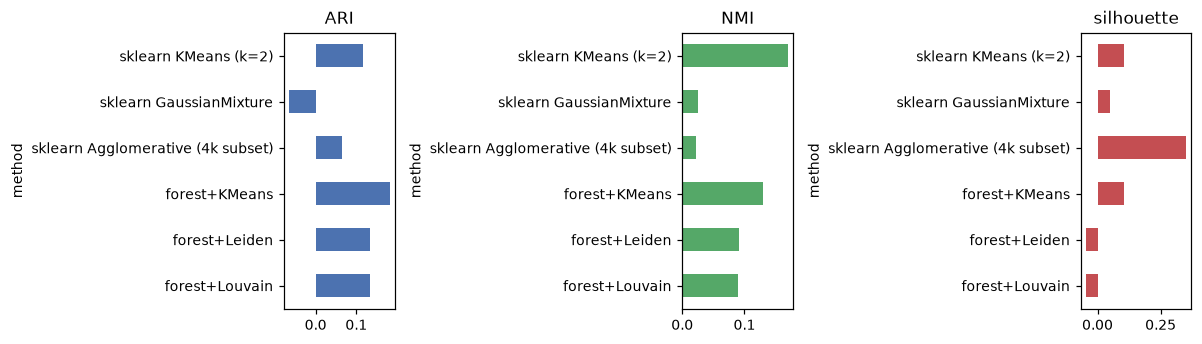

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, col, color in zip(ax, ["ARI", "NMI", "silhouette"], ["#4C72B0", "#55A868", "#C44E52"]):
    comp[col].plot.barh(ax=a, color=color)
    a.set_title(col); a.invert_yaxis()
plt.tight_layout(); plt.show()

**Reading the comparison.** On the income reference the methods are broadly comparable -- no
clusterer "solves" income because it is only one of several latent structures. The point is not
that the forest beats sklearn on this single label, but that:

- It handles the **mixed-type data natively** (no manual encoding pipeline).
- Its KMeans and graph paths run on the **full 48k rows** cheaply, whereas
  `AgglomerativeClustering` is `O(n^2)` and only ran on a 4k subset.
- It offers **graph community detection** (Louvain/Leiden) that discovers a data-driven number
  of clusters rather than a fixed `k`.

## 6. Comparing the library's own settings

The two most influential knobs are `n_bins` (`K`, bin granularity per feature) and
`n_iterations` (`L`, number of random partitions), plus the choice of `clusterer`.
We sweep a small grid and measure quality and runtime. *(Each configuration rebuilds its own
embedding -- that is the cost being measured.)*

In [12]:
grid = []
for n_bins in [3, 4, 6]:
    for n_iter in [100, 200]:
        t0 = time.time()
        fck = ForestClusterer(n_iterations=n_iter, n_bins=n_bins, n_clusters=2,
                              corr_threshold=None, random_state=RNG).fit_predict(X)
        grid.append({"n_bins": n_bins, "n_iter": n_iter,
                     "ARI": adjusted_rand_score(y, fck),
                     "NMI": normalized_mutual_info_score(y, fck),
                     "time_s": time.time() - t0})
grid_df = pd.DataFrame(grid)
grid_df.round(3)

,n_bins,n_iter,ARI,NMI,time_s
0,3,100,0.182,0.163,0.430
1,3,200,0.183,0.129,0.818
2,4,100,0.183,0.129,0.434
3,4,200,0.182,0.129,0.779
4,6,100,0.183,0.127,0.436
5,6,200,0.183,0.129,0.810


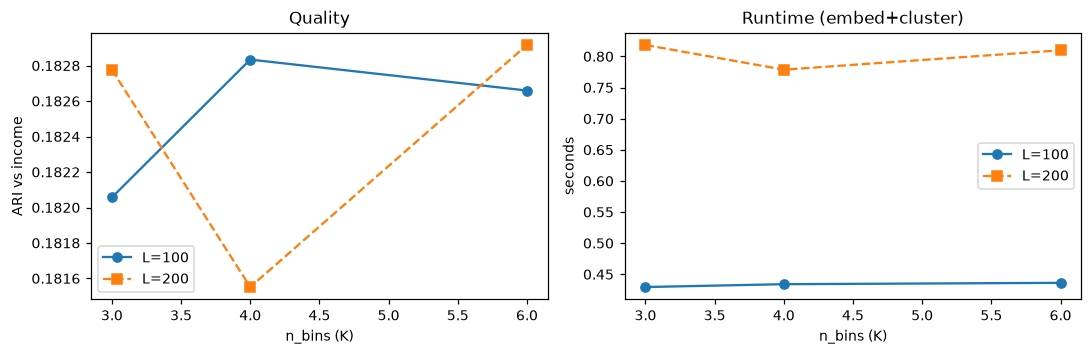

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
for n_iter, mk in zip([100, 200], ["o-", "s--"]):
    sub = grid_df[grid_df.n_iter == n_iter]
    ax[0].plot(sub.n_bins, sub.ARI, mk, label=f"L={n_iter}")
    ax[1].plot(sub.n_bins, sub.time_s, mk, label=f"L={n_iter}")
ax[0].set_xlabel("n_bins (K)"); ax[0].set_ylabel("ARI vs income"); ax[0].set_title("Quality"); ax[0].legend()
ax[1].set_xlabel("n_bins (K)"); ax[1].set_ylabel("seconds"); ax[1].set_title("Runtime (embed+cluster)"); ax[1].legend()
plt.tight_layout(); plt.show()

In [14]:
# Clusterer comparison at a fixed embedding setting: KMeans vs Louvain vs Leiden.
rows = []
for clu in ["kmeans", "louvain", "leiden"]:
    t0 = time.time()
    if clu == "kmeans":
        lab = ForestClusterer(n_iterations=200, n_bins=4, n_clusters=2,
                              corr_threshold=None, random_state=RNG).fit_predict(X)
    else:
        graph_spec = f"{clu}:k=100,resolution=0.05"
        lab = ForestClusterer(n_iterations=200, n_bins=4, clusterer=graph_spec,
                              corr_threshold=None, random_state=RNG).fit_predict(X)
    rows.append({"clusterer": clu, "clusters": len(np.unique(lab[lab >= 0])),
                 "ARI": adjusted_rand_score(y, lab),
                 "NMI": normalized_mutual_info_score(y, lab),
                 "time_s": round(time.time() - t0, 1)})
pd.DataFrame(rows).set_index("clusterer").round(3)

,clusters,ARI,NMI,time_s
clusterer,,,,
kmeans,2,0.182,0.129,0.7
louvain,51,0.128,0.086,35.8
leiden,51,0.128,0.087,15.3


**Settings takeaways.**

- **`n_bins` (K)** controls granularity: too few bins under-resolves structure, too many makes
  every cell nearly unique and similarity collapses. A small-to-moderate `K` (3-6) is the useful
  regime here.
- **`n_iterations` (L)** trades runtime for stability: more partitions give a smoother, more
  reliable similarity at roughly linear cost.
- **Clusterer**: KMeans needs a target `k` and is fastest; **Leiden** discovers the number of
  communities itself and is markedly faster than NetworkX **Louvain** on the same graph, which is
  why it is the recommended graph backend at scale. For graph clustering, increasing neighbour
  count `k` makes the graph more connected, while decreasing `resolution` produces fewer, larger
  communities.

## 7. Conclusions

- `forest_clustering` turns mixed numerical/categorical data into a uniform **random-partition
  similarity embedding** and clusters it with centroid or graph methods.
- On the **full 48k-row Adult** dataset it runs comfortably, because the large-`n` paths use a
  **sparse one-hot** representation and an **LSH-banding kNN graph** instead of a ~10 GB dense
  distance matrix.
- Against scikit-learn it is competitive on the (weak) income reference while being **simpler to
  apply** (native mixed-type input) and **more scalable** than `O(n^2)` methods like agglomerative
  clustering.
- Its own knobs behave predictably: moderate `K`, larger `L` for stability, and **Leiden** as the
  fast, self-tuning graph backend.

The income label is only a partial yardstick -- the real value is an **unsupervised view** of the
population (life-stage, occupation, working patterns) that no single label captures.